In [1]:
import pandas as pd
import numpy as np

import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install optuna netcdf4 h5netcdf

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    make_scorer
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelBinarizer, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, auc
import optuna
from functools import partial
from itertools import cycle

In [4]:
class MLModels:
    def __init__(self, X, y, models, preprocessor=None, test_size=0.2, random_state=111):
        """
        Initialize the storm prediction model framework with Optuna integration.
        
        Parameters:
        - X: Features DataFrame
        - y: Target variable
        - models: Dictionary of models to evaluate (name: model instance)
        - preprocessor: sklearn preprocessor pipeline
        - test_size: Proportion for test split
        - random_state: Random seed for reproducibility
        """
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.random_state = random_state
        self.models = models
        self.preprocessor = preprocessor
        self.trained_models = {}
        self.results = pd.DataFrame()
        self.y_pred_proba = {}
        self.y_pred = {}
        self.studies = {}  
        self.best_params = {}
        
    def set_models(self, models):
        """Update the models to be trained and evaluated."""
        self.models = models
        
    def _create_objective(self, model_name, pipeline):
        """Create an Optuna objective function for a specific model."""
        def objective(trial):
            params = {}
            
            if model_name == 'RandomForest':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'max_depth': trial.suggest_int('max_depth', 3, 30),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                    'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
                }
            elif model_name == 'GradientBoosting':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                    'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
                    'max_depth': trial.suggest_int('max_depth', 3, 10),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
                }
            elif model_name == 'SVM':
                params = {
                    'C': trial.suggest_float('C', 0.1, 10, log=True),
                    'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
                    'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
                    'degree': trial.suggest_int('degree', 2, 4) if params.get('kernel') == 'poly' else 3
                }
            
            # Clone the pipeline and set parameters
            current_pipeline = clone(pipeline)
            current_pipeline.set_params(**{f'classifier__{k}': v for k, v in params.items()})
            
            # Use cross-validation to evaluate performance
            roc_auc_multiclass = make_scorer(roc_auc_score, needs_proba=True, multi_class='ovr')
            
            score = cross_val_score(
                current_pipeline,
                self.X_train,
                self.y_train,
                cv=2,
                scoring=roc_auc_multiclass,
                n_jobs=-1
            ).mean()
            
            return score
        
        return objective
    
    def train_models(self, n_trials=50, timeout=None, direction='maximize', n_jobs=-1):
        """
        Train all specified models with Optuna hyperparameter optimization.
        
        Parameters:
        - n_trials: Number of optimization trials per model
        - timeout: Maximum time in seconds to spend on optimization per model
        - direction: Optimization direction ('maximize' or 'minimize')
        """
        self.trained_models = {}
        self.best_params = {}
        self.studies = {}
        
        for name, model in self.models.items():
            print(f"\nOptimizing {name} with Optuna...")
            
            # Create pipeline with preprocessor if it exists
            if self.preprocessor is not None:
                pipeline = Pipeline([
                    ('preprocessor', self.preprocessor),
                    ('classifier', model)
                ])
            else:
                pipeline = Pipeline([('classifier', model)])
            
            # Create study
            study = optuna.create_study(
                direction=direction,
                sampler=optuna.samplers.TPESampler(seed=self.random_state)
            )
            
            # Optimize
            objective = self._create_objective(name, pipeline)
            study.optimize(objective, n_trials=n_trials, timeout=timeout, n_jobs=n_jobs)
            
            self.studies[name] = study
            self.best_params[name] = study.best_params
            
            # Train final model with best parameters
            pipeline.set_params(**{f'classifier__{k}': v for k, v in study.best_params.items()})
            pipeline.fit(self.X_train, self.y_train)
            self.trained_models[name] = pipeline
            
            print(f"Best parameters for {name}: {study.best_params}")
            print(f"Best ROC AUC: {study.best_value:.4f}")
    
    def evaluate_models(self):
        """Evaluate all trained models on the test set."""
        metrics = []

        all_classes = np.unique(np.concatenate([self.y_train, self.y_test]))
        num_classes = len(all_classes)
    
        for name, model in self.trained_models.items():
            # Get predictions
            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)  # Probability of positive class

            if hasattr(model, 'predict_proba'):
                raw_proba = model.predict_proba(self.X_test)
                model_classes = model.named_steps['classifier'].classes_
    
                # If model missed any class during training, align manually
                aligned_proba = np.zeros((self.X_test.shape[0], num_classes))
                for i, cls in enumerate(model_classes):
                    col_idx = np.where(all_classes == cls)[0][0]
                    aligned_proba[:, col_idx] = raw_proba[:, i]
    
                y_pred_proba = aligned_proba
            else:
                y_pred_proba = np.zeros((self.X_test.shape[0], num_classes))
            
            self.y_pred[name] = y_pred
            self.y_pred_proba[name] = y_pred_proba

            y_test_bin = label_binarize(self.y_test, classes=all_classes)

            try:
                y_test_bin = label_binarize(self.y_test, classes=all_classes)
                roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr')
            except ValueError:
                roc_auc = float('nan')
        
            model_metrics = {
                'Model': name,
                'Accuracy': accuracy_score(self.y_test, y_pred),
                'Precision': precision_score(self.y_test, y_pred, average='macro', zero_division=1),
                'Recall': recall_score(self.y_test, y_pred, average='macro'),
                'F1': f1_score(self.y_test, y_pred, average='macro'),
                'ROC AUC': roc_auc,
                'Confusion Matrix': confusion_matrix(self.y_test, y_pred),
                'Classification Report': classification_report(self.y_test, y_pred, output_dict=True)
            }
            
            metrics.append(model_metrics)
        
        self.results = pd.DataFrame(metrics).set_index('Model')

        self.all_classes = np.unique(np.concatenate([self.y_train, self.y_test]))

    
    def get_feature_importances(self):
        """Get feature importances for tree-based models."""
        importances = {}
        
        for name, model in self.trained_models.items():
            classifier = model.named_steps['classifier']
            
            if hasattr(classifier, 'feature_importances_'):
                # Get feature names after preprocessing
                if self.preprocessor is not None:
                    try:
                        feature_names = self.preprocessor.get_feature_names_out()
                    except AttributeError:
                        feature_names = self.X_train.columns.tolist()
                else:
                    feature_names = self.X_train.columns.tolist()
                    
                importances[name] = pd.Series(
                    classifier.feature_importances_,
                    index=feature_names
                ).sort_values(ascending=False)
                
        return importances

    def plot_all_confusion_matrices(self):
        if not self.y_pred:
            print("No models") 
            return
    
        class_names = getattr(self, 'label_encoder', None)
        if class_names:
            class_names = class_names.classes_
        else:
            class_names = np.unique(self.y_test)
    
        n_models = len(self.y_pred)
        n_cols = 2
        n_rows = (n_models + 1) // n_cols
    
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
        axes = axes.flatten()
    
        for idx, (model_name, y_pred) in enumerate(self.y_pred.items()):
            cm = confusion_matrix(self.y_test, y_pred)
    
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=class_names,
                        ax=axes[idx])
            axes[idx].set_title(f"{model_name}")
            axes[idx].set_xlabel("Predicted")
            axes[idx].set_ylabel("Actual")
    
        # Hide any unused subplots
        for j in range(idx + 1, len(axes)):
            fig.delaxes(axes[j])
    
        plt.tight_layout()
        plt.show()

    def plot_all_roc_curves(self):
        if not self.y_pred_proba:
            print("No predictions to plot.")
            return
    
        # Binarize the test labels
        classes = self.all_classes
        y_test_bin = label_binarize(self.y_test, classes=classes)
        n_classes = len(classes)
    
        for model_name, y_score in self.y_pred_proba.items():
            if y_score.shape[1] != n_classes:
                print(f"Skipping {model_name}: y_score shape {y_score.shape} does not match {n_classes} classes.")
                continue
    
            fpr = {}
            tpr = {}
            roc_auc = {}
    
            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
    
            plt.figure(figsize=(8, 6))
            colors = cycle(plt.cm.get_cmap('tab10').colors)
    
            for i, color in zip(range(n_classes), colors):
                plt.plot(fpr[i], tpr[i], color=color, lw=2,
                         label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')
    
            plt.plot([0, 1], [0, 1], 'k--', lw=2)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve for {model_name}')
            plt.legend(loc='lower right')
            plt.grid(True)
            plt.show()

    
    def get_optuna_visualizations(self, model_name):
        """
        Generate Optuna visualizations for a specific model.
        
        Returns:
        - optimization_history: Plot of optimization history
        - param_importances: Plot of parameter importances
        """
        if model_name not in self.studies:
            raise ValueError(f"No study found for model: {model_name}")
            
        study = self.studies[model_name]
        
        history = optuna.visualization.plot_optimization_history(study)
        importances = optuna.visualization.plot_param_importances(study)
        
        return history, importances
    
    def __str__(self):
        return f"StormPredictionModels with {len(self.models)} models: {list(self.models.keys())}"

### Training/Testing

In [5]:
df = pd.read_csv('Stormevents/storm_events_cleaned.csv')

df = df[['Date', 'Latitude', 'Longitude', 'EVENT_TYPE']]

df['Date'] = pd.to_datetime(df['Date'])


/tmp/ipykernel_5999/1038700804.py:1: DtypeWarning: Columns (23,28,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Stormevents/storm_events_cleaned.csv')


In [6]:
file = ['s_sea_surface_temp.nc', 's_ERA-10u.nc', 'precip.nc', 's_ERA-10v.nc', 's_two_m_temp.nc', 's_two_m_dewpoint.nc', 's_evap_total_cloud_2005-2024.nc', 's_pressure_and_evaporation_data.nc']

ds_list = []

for f in file:
    ds = xr.open_dataset('Dataset_small/' + f).drop_vars(['number', 'step', 'surface'], errors='ignore')
    if 'valid_time' in ds.coords:
        ds = ds.rename({'valid_time': 'time'})
        

    ds_list.append(ds)

ds_nans = ds_list[:2] #sst and u10
ds_list = ds_list[2:]

for i, ds in enumerate(ds_list):
    ds_list[i] = ds.dropna(dim='latitude')
    ds_list[i] = ds.dropna(dim='longitude')
    print(i)
    print(ds_list[i])
    
    
common_times = set(ds_list[0].time.values)

for ds in ds_list[1:]:
    common_times = common_times.intersection(set(ds.time.values))
    
common_times = list(common_times)

datasets_common = [ds.sel(time=common_times) for ds in ds_list]

ds_combined = xr.merge(datasets_common, compat='override')

ds_clean = ds_combined.sel(latitude=ds.latitude[np.isclose(ds.latitude % 1, 0)], longitude=ds.longitude[np.isclose(ds.longitude % 1, 0)])

df_xr = ds_clean.to_dataframe().reset_index()

df_xr.rename(columns = {'time': 'Date', 'latitude': 'Latitude', 'longitude': 'Longitude'}, inplace=True)

df_xr.drop(columns='expver', inplace=True)

df_xr['Date'] = pd.to_datetime(df_xr['Date'])

df_xr['Latitude'] = df_xr['Latitude'].astype(int)
df_xr['Longitude'] = df_xr['Longitude'].astype(int)

0
<xarray.Dataset> Size: 121MB
Dimensions:    (time: 7305, latitude: 41, longitude: 101)
Coordinates:
  * time       (time) datetime64[ns] 58kB 2005-01-01 2005-01-02 ... 2024-12-31
  * latitude   (latitude) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25.25 25.0
  * longitude  (longitude) float64 808B -100.0 -99.75 -99.5 ... -75.25 -75.0
    expver     (time) <U4 117kB ...
Data variables:
    tp         (time, latitude, longitude) float32 121MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-03T06:51 GRIB to CDM+CF via cfgrib-0.9.1...
1
<xarray.Dataset> Size: 122MB
Dimensions:    (time: 7391, latitude: 41, longitude: 101)
Coordinates:
  * latitude   (latitude) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25

In [7]:
full_df = pd.merge(df_xr, df, on=['Date', 'Latitude', 'Longitude'], how='inner')

full_df

,Date,Latitude,Longitude,tp,v10,t2m,d2m,tcc,msl,sp,EVENT_TYPE
0,2005-01-02,34,-96,0.000000,2.239624,291.413940,289.127930,0.839546,102110.937500,100097.187500,Flash Flood
1,2005-01-02,32,-97,0.000009,3.568970,292.366089,290.174805,0.864334,102065.687500,99931.687500,Flash Flood
2,2005-01-03,34,-97,0.000003,1.566856,290.007935,289.673401,1.000000,102046.453125,99266.171875,Flash Flood
3,2005-01-03,34,-96,0.000674,3.555626,290.697388,290.336487,1.000000,102078.203125,100065.921875,Flash Flood
4,2005-01-03,33,-97,0.000651,3.988487,291.708618,291.072327,1.000000,102035.484375,99943.671875,Flash Flood
...,...,...,...,...,...,...,...,...,...,...,...
166510,2011-05-26,29,-97,0.000000,0.651897,302.078491,295.627014,0.140167,100997.640625,100422.000000,Hail
166511,2011-05-26,29,-97,0.000000,0.651897,302.078491,295.627014,0.140167,100997.640625,100422.000000,Hail
166512,2011-05-26,29,-97,0.000000,0.651897,302.078491,295.627014,0.140167,100997.640625,100422.000000,Hail
166513,2011-05-26,29,-96,0.000000,1.033489,302.576538,295.475647,0.200523,101011.640625,100817.250000,Thunderstorm Wind


In [8]:
def preprocess_datetime(X, datetime_cols):
    X = X.copy()
    for col in datetime_cols:
        X[f'{col}_year'] = X[col].dt.year
        X[f'{col}_month'] = X[col].dt.month
        X[f'{col}_day'] = X[col].dt.day
    return X.drop(columns=datetime_cols)

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

y = df['EVENT_TYPE']
X = df.drop(columns=['EVENT_TYPE'])

datetime_cols = X.select_dtypes(include='datetime64').columns.tolist()

X_cleaned = preprocess_datetime(X, datetime_cols)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

categorical_cols = []
numerical_cols = X_cleaned.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
])

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    # 'SVM': SVC(probability=True, random_state=42)
}

ml = MLModels(X_cleaned, y_encoded, models, preprocessor=preprocessor)

ml.train_models(n_trials=3)

ml.evaluate_models()

print(ml.results)

[I 2025-06-05 08:22:08,679] A new study created in memory with name: no-name-4366332f-6003-4664-9caa-ac83ae4ff768



Optimizing RandomForest with Optuna...


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
[I 2025-06-05 08:22:15,578] Trial 0 finished with value: 0.8262620319675985 and parameters: {'n_estimators': 52, 'max_depth': 25, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.8262620319675985.
[I 2025-06-05 08:22:33,480] Trial 1 finished with value: 0.8758688193723251 and parameters: {'n_estim

Best parameters for RandomForest: {'n_estimators': 277, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}
Best ROC AUC: 0.8759

Optimizing GradientBoosting with Optuna...


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
[I 2025-06-05 08:25:45,230] Trial 0 finished with value: 0

Best parameters for GradientBoosting: {'n_estimators': 474, 'learning_rate': 0.008714712891014668, 'max_depth': 3, 'min_samples_split': 11, 'min_samples_leaf': 7, 'subsample': 0.8055556989039347, 'max_features': 'log2'}
Best ROC AUC: 0.8215


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  Accuracy  Precision    Recall        F1  ROC AUC  \
Model                                                                
RandomForest      0.673840   0.768247  0.308413  0.340588      NaN   
GradientBoosting  0.573519   0.786185  0.211868  0.212875      NaN   

                                                   Confusion Matrix  \
Model                                                                 
RandomForest      [[0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 6, 0], [0, 2, ...   
GradientBoosting  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0], [0, 2, ...   

                                              Classification Report  
Model                                                                
RandomForest      {'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc...  
GradientBoosting  {'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc...  


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


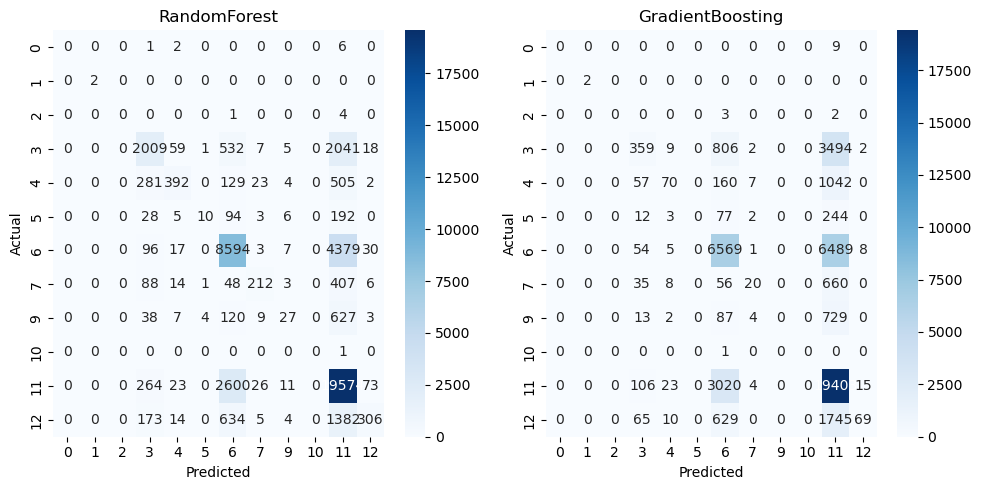

In [10]:
ml.plot_all_confusion_matrices()

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/tmp/ipykernel_5999/1629342830.py:272: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cycle(plt.cm.get_cmap('tab10').colors)


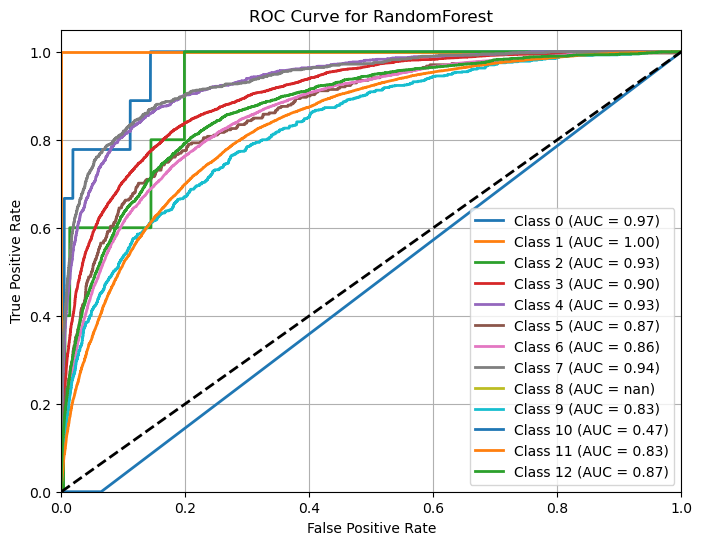

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/tmp/ipykernel_5999/1629342830.py:272: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cycle(plt.cm.get_cmap('tab10').colors)


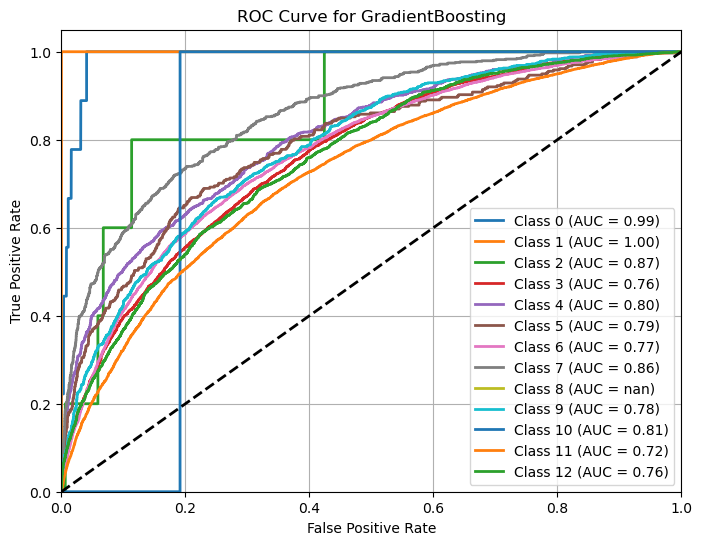

In [11]:
ml.plot_all_roc_curves()
